# Phase 2 — Sparse Component Analysis (SCA) analysis

This notebook analyses the **saved SCA fits** produced by `03_Primitive_Discovery.ipynb`. It does not retrain SCA.

SCA has a different role from FADA in this project. The data passed to SCA have shape

$$
(N_{trials}T)\times D,
$$

where `D` is the number of joint coordinates. SCA therefore learns a sparse low-rank representation of **instantaneous joint coordination**. Its component count `K` is a joint-space rank, not directly a count of complete movement primitives.

With seven input joints:

- `K < 7` is dimensionality reduction;
- `K = 7` is a full-rank reference;
- reconstruction approaching perfection near `K=7` is therefore expected.

The analysis focuses on four questions:

1. How efficiently does SCA compress joint-space activity relative to PCA?
2. What joint-loading pattern does each SCA factor represent?
3. Are the latent activations actually sparse and selectively recruited over movement phase?
4. Do similar joint factors persist across K, subjects, conditions, and the `q` versus `f` representations?

The notebook deliberately avoids interpreting SCA's K as a motor-primitive count.


## 1. Locate the saved SCA experiment

### Why

As with FADA, analysis must remain tied to the exact dataset, view and split that generated the saved fit parameters. SCA fit files are stored separately for `q`, `f` and each K.

### What this cell controls

`INSPECT_K` chooses a rank for detailed loading/activation plots. If left as `None`, the notebook chooses the largest **reduced-rank** fit (`D-1`) when available rather than the full-rank reference. This is only a display convenience.

No SCA fitting happens in this notebook.


In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA

from motion_primitives.paths import PROJECT_ROOT
from motion_primitives.preprocessing import load_collections

COLLECTION = PROJECT_ROOT / 'collections/3D-ARM-Gaze/custom-phase200-v1'
VIEW = 'successful'
SPLIT_METHOD = 'random_trial'
JOINT_NAMES = None
SEED = 42

INSPECT_K = 4

DISCOVERY_OUTPUT = (PROJECT_ROOT / 'notebooks/results/03_Primitive_Discovery' /
                    COLLECTION.name / VIEW / SPLIT_METHOD)
SCA_OUTPUT = DISCOVERY_OUTPUT / 'sca'
ANALYSIS_OUTPUT = (PROJECT_ROOT / 'notebooks/results/05_SCA_Analysis' /
                   COLLECTION.name / VIEW / SPLIT_METHOD)
ANALYSIS_OUTPUT.mkdir(parents=True, exist_ok=True)


## 2. Load trajectories, trial metadata and the exact saved split

### Why

The SCA parameters `U`, `V`, `b_u` and `b_v` are sufficient to reconstruct latent activity, but they are meaningful only with the same joint ordering and trial ordering used during fitting.

### How

We reload the prepared collection and the saved split. The notebook refuses to continue if the trial IDs do not match in order. We also load the summary generated during discovery and determine the full input rank directly from the number of joints.

### What to verify

For the current ARM-Gaze representation the full rank should be `7`. The available K values should run up to that rank. `INSPECT_K` is chosen below full rank by default so that the detailed plots describe an actual compressed representation.


In [13]:
collection = load_collections([COLLECTION], JOINT_NAMES, view=VIEW)
Q = collection['q']
F = collection['f']
metadata = collection['metadata'].reset_index(drop=True)
joints = list(collection['joint_names'])

split_path = DISCOVERY_OUTPUT / f'split_{SPLIT_METHOD}.csv'
saved_split = pd.read_csv(split_path)
if saved_split.trial_id.tolist() != metadata.trial_id.tolist():
    raise ValueError('Saved split does not match the ordered trial cohort.')
split = saved_split.split.to_numpy()

provenance = json.loads((DISCOVERY_OUTPUT / 'provenance.json').read_text())
sca_summary = pd.read_csv(SCA_OUTPUT / 'summary.csv')
AVAILABLE_K = sorted(int(k) for k in sca_summary['k'].unique())
FULL_RANK = Q.shape[2]

if INSPECT_K is None:
    reduced = [k for k in AVAILABLE_K if k < FULL_RANK]
    INSPECT_K = reduced[-1] if reduced else AVAILABLE_K[-1]
if INSPECT_K not in AVAILABLE_K:
    raise ValueError(f'INSPECT_K={INSPECT_K} is not available: {AVAILABLE_K}')

print(f'{len(metadata)} trials, {Q.shape[1]} phase samples, {FULL_RANK} joints')
print(f'Available SCA K: {AVAILABLE_K}')
print(f'Full joint rank: {FULL_RANK}')
print(f'Detailed inspection K: {INSPECT_K} (display choice only)')


17007 trials, 200 phase samples, 7 joints
Available SCA K: [1, 2, 3, 4, 5, 6, 7]
Full joint rank: 7
Detailed inspection K: 4 (display choice only)


## 3. Recover the linear SCA transform from the saved parameters

### Why

The discovery notebook saved the learned SCA parameters rather than every time-resolved latent trajectory. That is enough because the fitted SCA model is linear in the current analysis.

### How

For an input joint vector `x`, the saved model uses

$$
z = xU + b_u,
$$

followed by

$$
\hat x = zV + b_v.
$$

`U` therefore maps joint coordinates into latent factors, while each row of `V` describes how one latent factor contributes back to the joints.

The helper below reconstructs both `z(t)` and `x_hat(t)` for every trial **without training anything**.

### Interpretation caution

The sign of a latent factor is arbitrary: flipping one factor in both encoder/decoder leaves the represented subspace unchanged. Comparisons between fits therefore use absolute cosine similarity or a deterministic display sign.


In [14]:
def load_sca_fit(representation, k):
    path = SCA_OUTPUT / representation / f'k{k:02d}' / 'fit.npz'
    if not path.exists():
        raise FileNotFoundError(path)
    with np.load(path) as saved:
        return {name: saved[name] for name in saved.files}


def sca_transform(values, fit):
    U = fit['param_U']
    b_u = fit['param_b_u']
    return values @ U + b_u


def sca_reconstruct(values, fit):
    z = sca_transform(values, fit)
    return z @ fit['param_V'] + fit['param_b_v']


def nmse(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    center_axes = tuple(range(actual.ndim - 1))
    mean = actual.mean(axis=center_axes, keepdims=True)
    denom = np.sum((actual - mean) ** 2)
    return np.sum((actual - predicted) ** 2) / denom


def row_normalize(matrix):
    matrix = np.asarray(matrix, dtype=float)
    norm = np.linalg.norm(matrix, axis=1, keepdims=True)
    return np.divide(matrix, norm, out=np.zeros_like(matrix), where=norm != 0)


def canonicalize_rows_for_display(matrix):
    rows = row_normalize(matrix)
    peak = np.argmax(np.abs(rows), axis=1)
    signs = np.sign(rows[np.arange(len(rows)), peak])
    signs[signs == 0] = 1
    return rows * signs[:, None]


## 4. Rank curve, with PCA as a reconstruction reference

### Why compare SCA with PCA?

PCA is the standard linear low-rank reconstruction baseline. For a fixed rank K, PCA is optimized to retain variance efficiently, whereas SCA deliberately adds a sparsity objective and a factor-geometry constraint. SCA may therefore accept some reconstruction cost in exchange for more separable/sparse latent factors.

Without a PCA reference, a statement such as "SCA needs six dimensions" is hard to interpret: perhaps any linear model needs six dimensions, or perhaps the sparsity constraint is responsible for the extra error.

### How

For each representation we fit **one full-rank PCA** on discovery samples only. We then reconstruct the held-out test samples using the first K principal axes. This avoids refitting PCA K times and does not touch the saved SCA model.

We compare:

$$
\mathrm{NMSE}_{SCA}(K)
\quad\text{vs}\quad
\mathrm{NMSE}_{PCA}(K).
$$

### Interpretation

- PCA answers how much low-rank linear compression is possible when reconstruction is the main objective.
- SCA answers how much reconstruction remains after imposing its sparse component structure.
- `K = D` is a full-rank sanity reference, not evidence for D primitives.


,representation,k,rank,nmse,test_nmse,sca_minus_pca_nmse
0,q,1,reduced_rank,6.189225e-01,6.183813e-01,5.411904e-04
1,q,2,reduced_rank,3.305762e-01,3.303835e-01,1.927812e-04
2,q,3,reduced_rank,2.226680e-01,2.226222e-01,4.580064e-05
3,q,4,reduced_rank,1.421831e-01,1.421640e-01,1.906803e-05
4,q,5,reduced_rank,8.016144e-02,8.015480e-02,6.643961e-06
5,q,6,reduced_rank,2.852492e-02,2.852362e-02,1.300177e-06
6,q,7,full_rank,1.029960e-10,7.531238e-31,1.029960e-10
7,f,1,reduced_rank,5.779484e-01,5.757842e-01,2.164137e-03
8,f,2,reduced_rank,3.147733e-01,3.144284e-01,3.448566e-04
9,f,3,reduced_rank,2.092767e-01,2.091526e-01,1.240486e-04


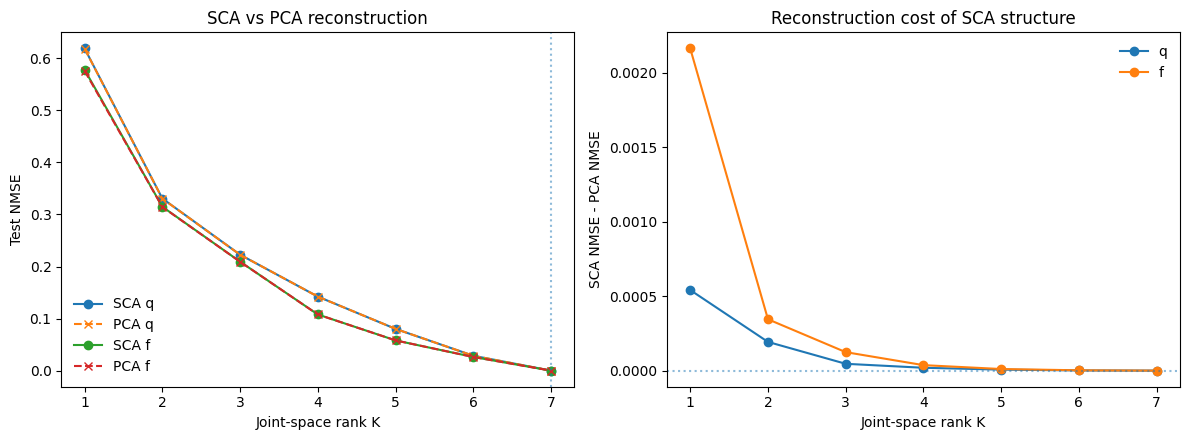

In [15]:
pca_rows = []
for representation, values in [('q', Q), ('f', F)]:
    train = values[split == 'discovery'].reshape(-1, FULL_RANK)
    test = values[split == 'test'].reshape(-1, FULL_RANK)

    pca = PCA(n_components=FULL_RANK, svd_solver='full')
    pca.fit(train)
    centered_test = test - pca.mean_

    for k in AVAILABLE_K:
        components = pca.components_[:k]
        scores = centered_test @ components.T
        reconstruction = scores @ components + pca.mean_
        pca_rows.append({
            'representation': representation,
            'k': k,
            'test_nmse': nmse(test, reconstruction),
        })

pca_summary = pd.DataFrame(pca_rows)
test_sca = sca_summary[sca_summary['split'] == 'test'].copy()
comparison = test_sca.merge(pca_summary, on=['representation', 'k'], suffixes=('_sca', '_pca'))
comparison['sca_minus_pca_nmse'] = comparison['nmse'] - comparison['test_nmse']
display(comparison[['representation', 'k', 'rank', 'nmse', 'test_nmse', 'sca_minus_pca_nmse']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for representation in ('q', 'f'):
    rows = comparison[comparison.representation == representation].sort_values('k')
    axes[0].plot(rows.k, rows.nmse, marker='o', label=f'SCA {representation}')
    axes[0].plot(rows.k, rows.test_nmse, marker='x', linestyle='--', label=f'PCA {representation}')
    axes[1].plot(rows.k, rows.sca_minus_pca_nmse, marker='o', label=representation)
axes[0].axvline(FULL_RANK, linestyle=':', alpha=0.5)
axes[0].set(xlabel='Joint-space rank K', ylabel='Test NMSE', title='SCA vs PCA reconstruction')
axes[1].axhline(0, linestyle=':', alpha=0.5)
axes[1].set(xlabel='Joint-space rank K', ylabel='SCA NMSE - PCA NMSE',
            title='Reconstruction cost of SCA structure')
for ax in axes:
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / 'sca_vs_pca_rank_curve.png', bbox_inches='tight')
plt.show()


## 5. Inspect the learned joint-loading factors

### Why

The decoder matrix `V` is the most direct description of what an SCA component means in joint space. Row `k` of `V` gives the joint pattern produced by latent factor `k`.

### How

For `INSPECT_K`, we display one row per component and one column per joint. Each row is normalized and given a deterministic sign **only for visualization**. The original parameters remain untouched.

### What to look for

- Does a factor emphasize a coherent subset of joints?
- Are proximal and distal joints grouped differently?
- Are multiple factors almost identical?
- Does residualization (`f`) reveal different joint coordination axes from raw `q`?

Because SCA is an instantaneous joint-space factorization, these loadings are better described as **coordination factors** than as complete movement primitives.


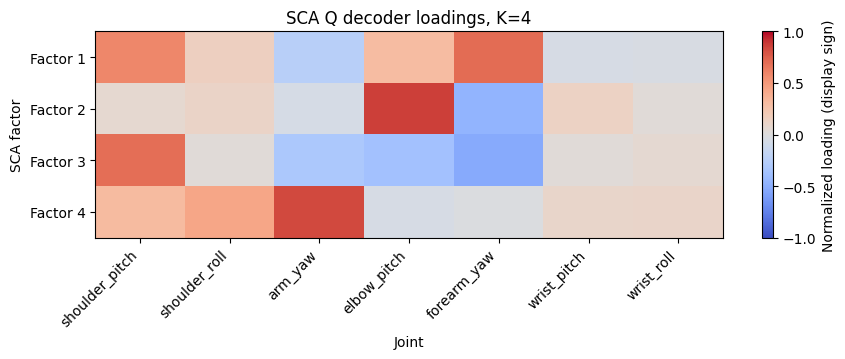

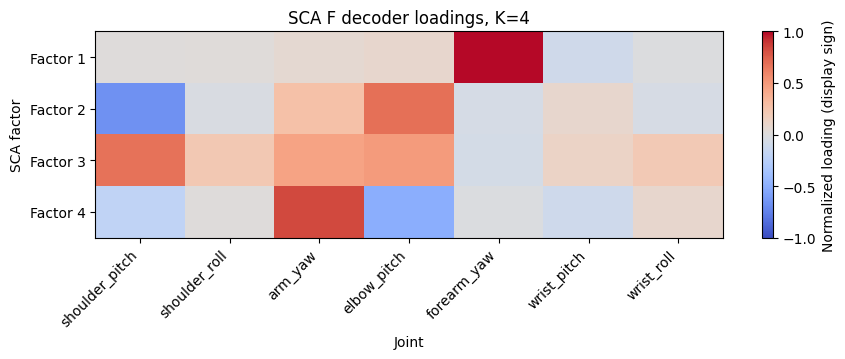

In [16]:
for representation in ('q', 'f'):
    fit = load_sca_fit(representation, INSPECT_K)
    V = canonicalize_rows_for_display(fit['param_V'])

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.55 * INSPECT_K + 1.5)))
    image = ax.imshow(V, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(FULL_RANK))
    ax.set_xticklabels(joints, rotation=45, ha='right')
    ax.set_yticks(range(INSPECT_K))
    ax.set_yticklabels([f'Factor {i + 1}' for i in range(INSPECT_K)])
    ax.set(title=f'SCA {representation.upper()} decoder loadings, K={INSPECT_K}',
           xlabel='Joint', ylabel='SCA factor')
    fig.colorbar(image, ax=ax, label='Normalized loading (display sign)')
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT / f'{representation}_k{INSPECT_K:02d}_joint_loadings.png',
                bbox_inches='tight')
    plt.show()


## 6. Recover time-resolved latent activations

### Why

Although SCA is fitted after stacking all trial time points, the latent variables can be reshaped back into individual trajectories. This lets us ask **when during a movement** each joint-coordination factor is active.

### How

For every trial and phase sample we compute

$$
z_a(t)=q_a(t)U+b_u
$$

(or the same expression using `f`). The first plot shows mean **absolute** activation over held-out test trials because absolute magnitude measures recruitment without cancellation between positive and negative activations. We then show a few signed example trajectories so temporal structure is still visible.

### Interpretation

A factor with a clear phase-dependent activation profile may describe a coordination pattern preferentially expressed at a particular movement stage. A flat profile means the factor is used more uniformly over phase.

This does not make the factor a FADA-like temporal primitive: the temporal activation is free to change at every time point.


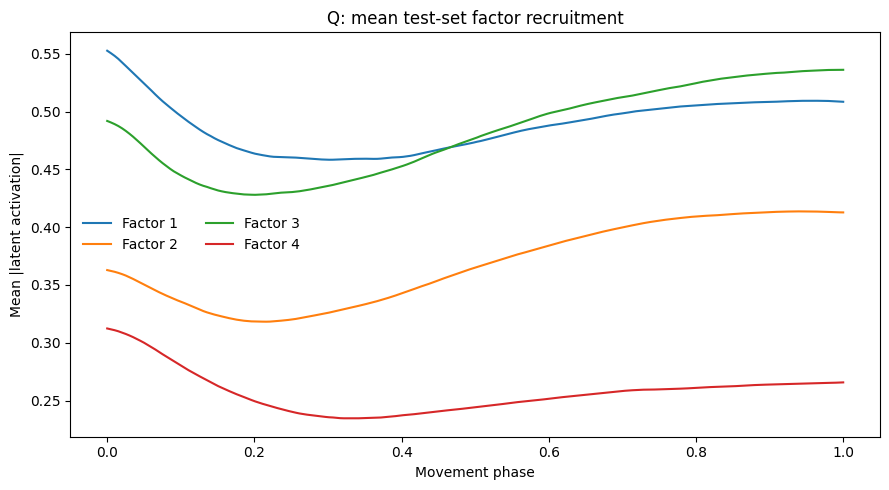

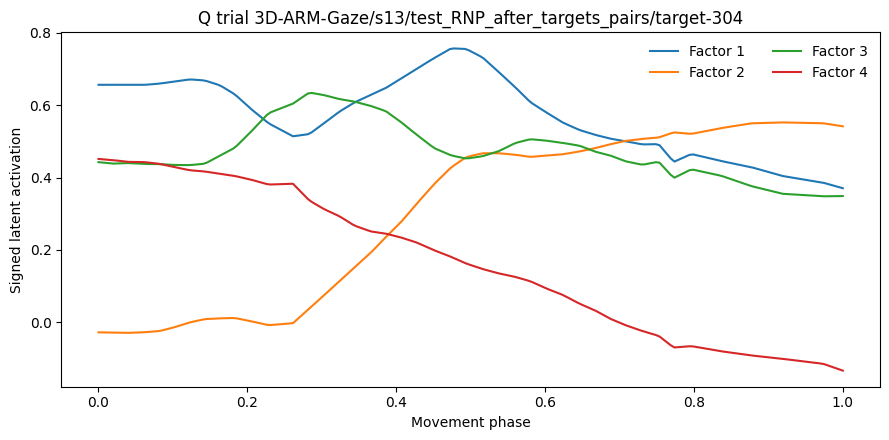

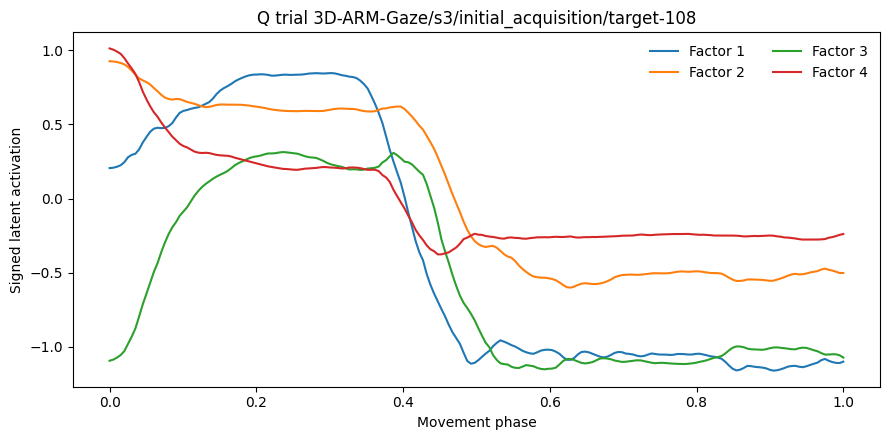

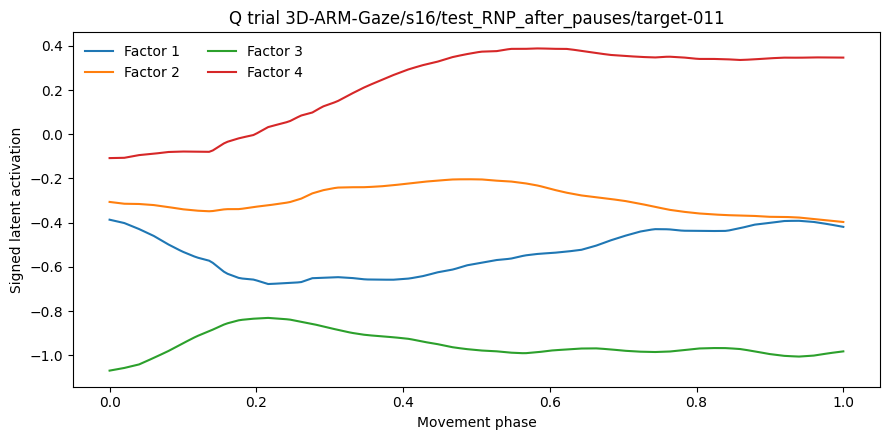

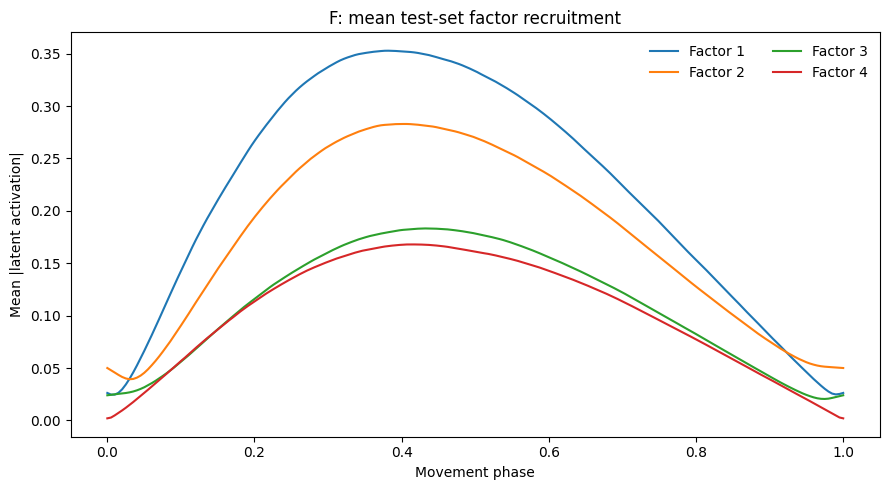

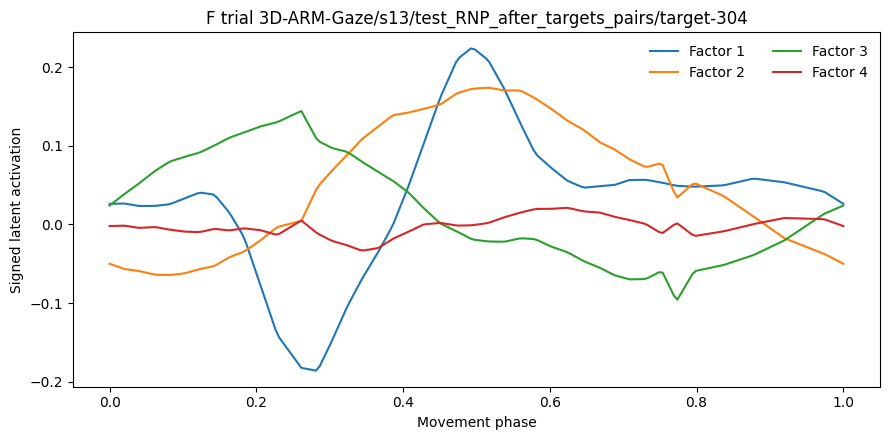

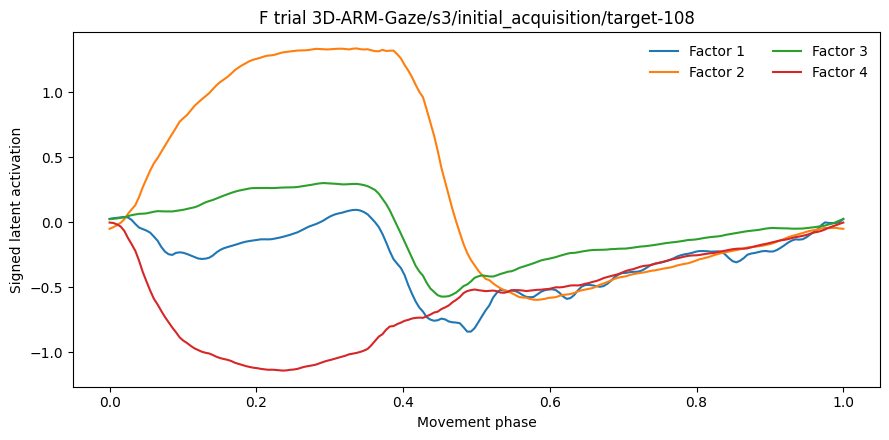

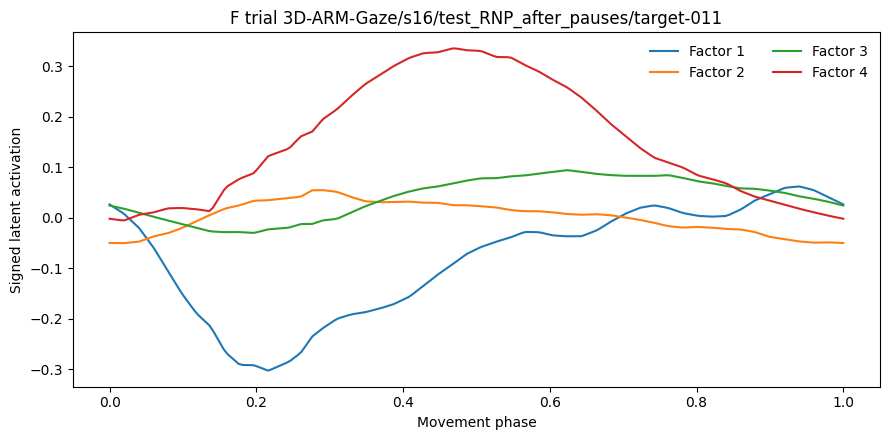

In [17]:
phase = np.linspace(0, 1, Q.shape[1])
test_mask = split == 'test'
rng = np.random.default_rng(SEED)
example_indices = rng.choice(np.flatnonzero(test_mask), size=min(3, test_mask.sum()), replace=False)

for representation, values in [('q', Q), ('f', F)]:
    fit = load_sca_fit(representation, INSPECT_K)
    z = sca_transform(values, fit)

    mean_abs = np.mean(np.abs(z[test_mask]), axis=0)  # [phase, K]
    fig, ax = plt.subplots(figsize=(9, 5))
    for k in range(INSPECT_K):
        ax.plot(phase, mean_abs[:, k], label=f'Factor {k + 1}')
    ax.set(xlabel='Movement phase', ylabel='Mean |latent activation|',
           title=f'{representation.upper()}: mean test-set factor recruitment')
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT / f'{representation}_k{INSPECT_K:02d}_mean_activation.png',
                bbox_inches='tight')
    plt.show()

    for trial_idx in example_indices:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        for k in range(INSPECT_K):
            ax.plot(phase, z[trial_idx, :, k], label=f'Factor {k + 1}')
        ax.set(xlabel='Movement phase', ylabel='Signed latent activation',
               title=f'{representation.upper()} trial {metadata.loc[trial_idx, "trial_id"]}')
        ax.legend(frameon=False, ncol=2)
        fig.tight_layout()
        plt.show()


## 7. Measure sparsity rather than assuming it

### Why

Sparsity is central to SCA's purpose. Reconstruction error alone does not tell us whether the learned representation actually uses a small subset of factors at any given time or whether all factors remain broadly active.

### Two complementary measures

**Hoyer sparsity** of the instantaneous latent vector `z(t)` is

$$
S_H(z)=\frac{\sqrt K-\|z\|_1/\|z\|_2}{\sqrt K-1}.
$$

It lies between approximately `0` (distributed activity) and `1` (one active dimension). It is undefined for `K=1`, so that case is omitted.

We also compute a **trial-level effective factor count**. For each trial we average `|z_k(t)|` across phase, normalize these values into shares `p_k`, then calculate

$$
N_{eff}=\frac{1}{\sum_k p_k^2}.
$$

This tells us how many factors meaningfully contribute over the whole movement.

### What to compare

The main comparison is `q` versus `f` at the same K. If residualization produces similar reconstruction with higher sparsity/lower effective factor count, that would support the idea that endpoint removal exposes a more compact coordination structure.


,representation,k,mean_hoyer_sparsity,median_effective_factors
0,q,1,NaN,1.000000
1,q,2,0.360764,1.825180
2,q,3,0.346957,2.489202
3,q,4,0.326569,3.230479
4,q,5,0.335418,3.817019
5,q,6,0.337575,4.411485
6,q,7,0.535226,3.197951
7,f,1,NaN,1.000000
8,f,2,0.350350,1.809347
9,f,3,0.350459,2.455333


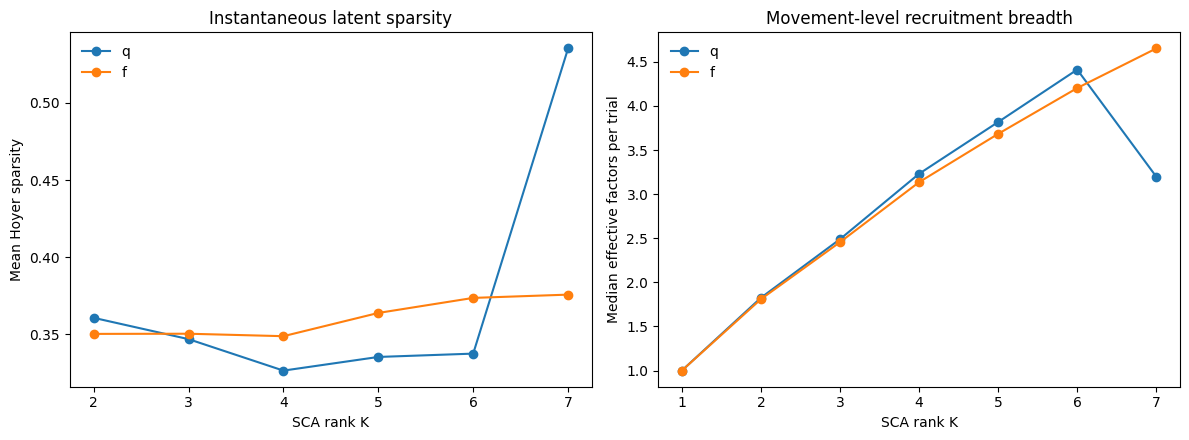

In [18]:
def hoyer_sparsity(z):
    k = z.shape[-1]
    if k <= 1:
        return np.full(z.shape[:-1], np.nan)
    l1 = np.sum(np.abs(z), axis=-1)
    l2 = np.linalg.norm(z, axis=-1)
    ratio = np.divide(l1, l2, out=np.full_like(l1, np.nan, dtype=float), where=l2 != 0)
    return (np.sqrt(k) - ratio) / (np.sqrt(k) - 1)


def trial_effective_factors(z):
    activity = np.mean(np.abs(z), axis=1)
    total = activity.sum(axis=1, keepdims=True)
    shares = np.divide(activity, total, out=np.zeros_like(activity), where=total != 0)
    return 1.0 / np.sum(shares ** 2, axis=1), shares

sparsity_rows = []
for representation, values in [('q', Q), ('f', F)]:
    for k in AVAILABLE_K:
        fit = load_sca_fit(representation, k)
        z = sca_transform(values[test_mask], fit)
        hoyer = hoyer_sparsity(z)
        effective, _ = trial_effective_factors(z)
        sparsity_rows.append({
            'representation': representation,
            'k': k,
            'mean_hoyer_sparsity': float(np.nanmean(hoyer)) if k > 1 else np.nan,
            'median_effective_factors': float(np.median(effective)),
        })

sparsity_summary = pd.DataFrame(sparsity_rows)
display(sparsity_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for representation in ('q', 'f'):
    rows = sparsity_summary[sparsity_summary.representation == representation]
    axes[0].plot(rows.k, rows.mean_hoyer_sparsity, marker='o', label=representation)
    axes[1].plot(rows.k, rows.median_effective_factors, marker='o', label=representation)
axes[0].set(xlabel='SCA rank K', ylabel='Mean Hoyer sparsity', title='Instantaneous latent sparsity')
axes[1].set(xlabel='SCA rank K', ylabel='Median effective factors per trial',
            title='Movement-level recruitment breadth')
for ax in axes:
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / 'sca_sparsity_vs_k.png', bbox_inches='tight')
plt.show()


## 8. Reuse across subjects and experimental conditions

### Why

A sparse factor is more useful as a shared coordination structure if it appears across many movement realizations. If one factor is almost exclusively associated with one subject, the decomposition may be encoding individual idiosyncrasy. If factors change with condition, that may instead reflect experimentally meaningful adaptation.

### How

For the selected K we compute each trial's mean absolute latent activation over phase and normalize those activations into within-trial shares. We then average shares by metadata group.

This makes the heatmaps comparable across trials with different overall movement magnitudes and avoids choosing an arbitrary binary activation threshold.

### Interpretation

The goal is not to demand identical usage across all groups. Rather, we want to see whether factors are broadly reusable and whether systematic group differences are scientifically interpretable.


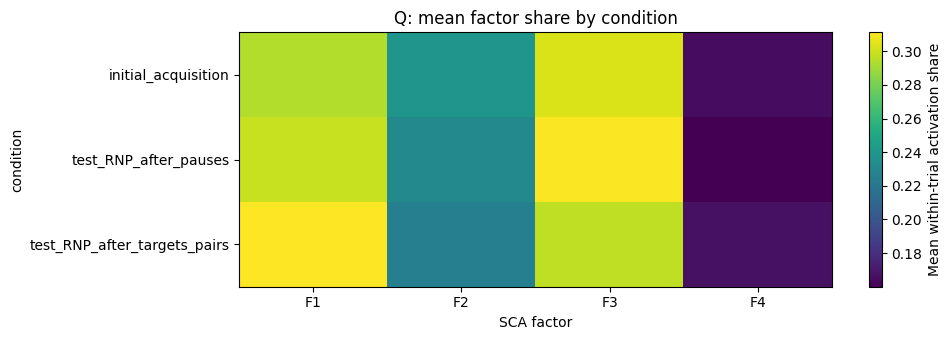

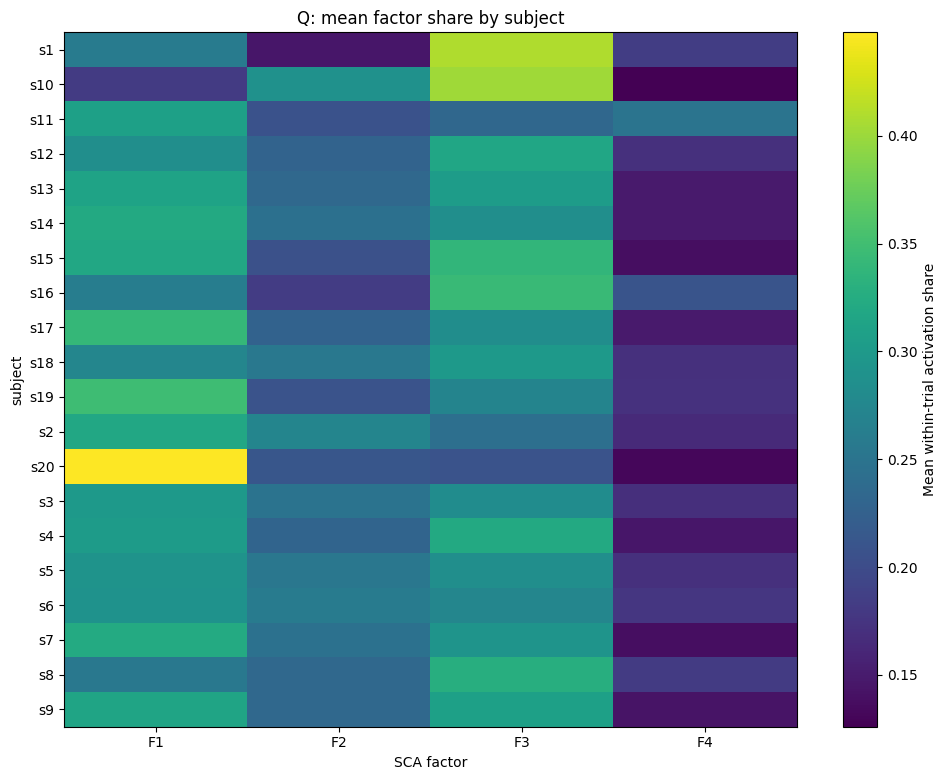

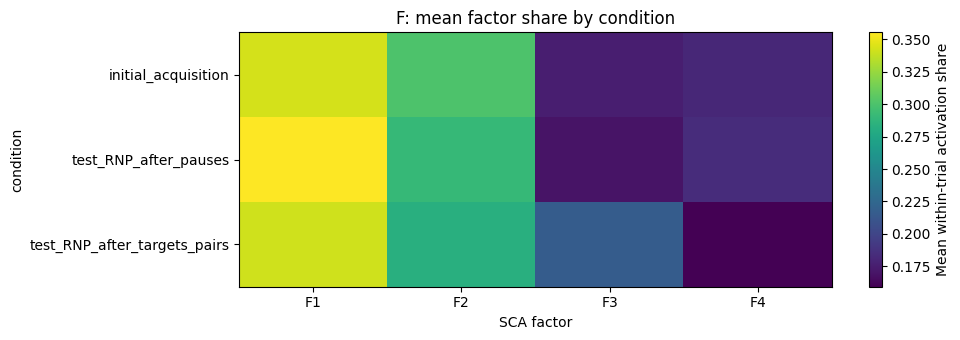

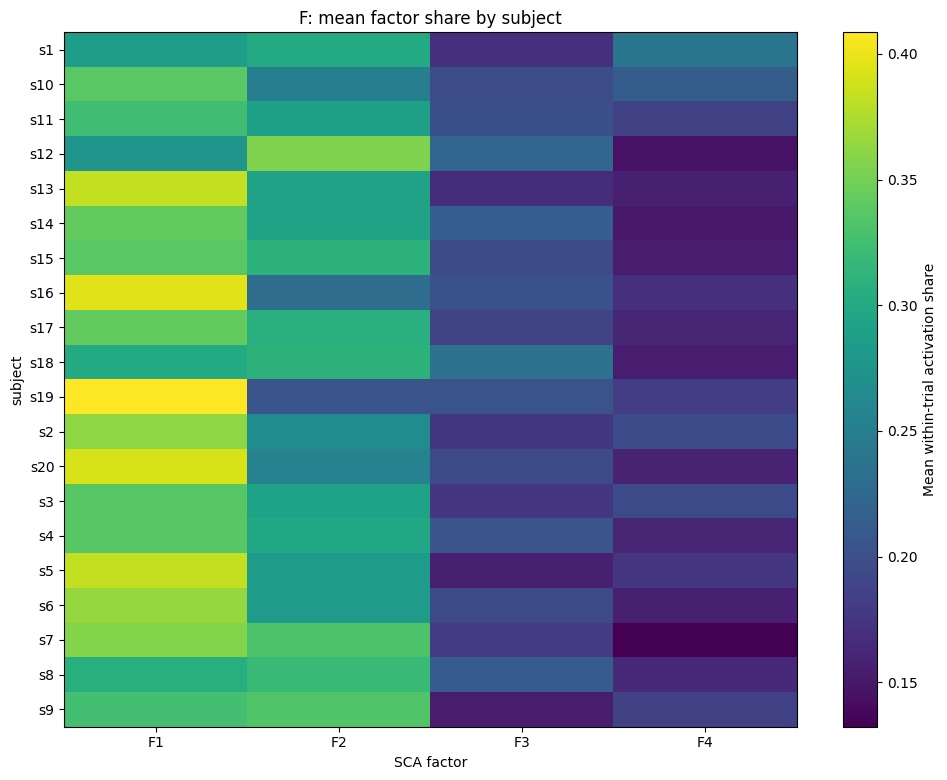

In [19]:
def sca_trial_shares(representation, k):
    values = Q if representation == 'q' else F
    fit = load_sca_fit(representation, k)
    z = sca_transform(values, fit)
    _, shares = trial_effective_factors(z)
    return shares


def plot_group_reuse(representation, k, group_col):
    if group_col not in metadata.columns:
        return
    shares = sca_trial_shares(representation, k)
    frame = metadata[[group_col]].copy()
    for i in range(k):
        frame[f'F{i + 1}'] = shares[:, i]
    grouped = frame.groupby(group_col, dropna=False).mean(numeric_only=True)
    if len(grouped) < 2:
        return

    fig_height = max(3.5, 0.32 * len(grouped) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    image = ax.imshow(grouped.to_numpy(), aspect='auto')
    ax.set_xticks(range(k))
    ax.set_xticklabels([f'F{i + 1}' for i in range(k)])
    ax.set_yticks(range(len(grouped)))
    ax.set_yticklabels([str(x) for x in grouped.index])
    ax.set(xlabel='SCA factor', ylabel=group_col,
           title=f'{representation.upper()}: mean factor share by {group_col}')
    fig.colorbar(image, ax=ax, label='Mean within-trial activation share')
    fig.tight_layout()
    fig.savefig(ANALYSIS_OUTPUT /
                f'{representation}_k{k:02d}_reuse_by_{group_col}.png', bbox_inches='tight')
    plt.show()

for representation in ('q', 'f'):
    for group_col in ('condition', 'subject', 'action'):
        plot_group_reuse(representation, INSPECT_K, group_col)


## 9. Persistence of joint factors across K

### Why

Factor numbering is arbitrary across independently fitted SCA models. We therefore need to match factors by their **joint-loading pattern**, not by row number.

A coordination axis that appears at K=3 and remains recognizable at K=4,5,6 is more structurally robust than one that exists only for a single rank.

### How

For two decoder matrices `V_K` and `V_{K+1}` we row-normalize the joint-loading vectors and compute

$$
S_{ij}=|v_i^T v_j|,
$$

which is absolute cosine similarity. The absolute value removes arbitrary factor sign.

We then use the Hungarian assignment algorithm to find the one-to-one pairing with the largest total similarity. Because K differs by one, one factor in the larger model remains unmatched.

### Interpretation

High matched cosine similarity means that an existing joint-coordination pattern survived when rank increased. Low similarity means the basis is reorganizing rather than simply adding a new factor.


,representation,k_from,k_to,factor_from,factor_to,abs_cosine
0,q,1,2,1,1,0.931305
1,q,2,3,1,1,0.976223
2,q,2,3,2,3,0.998933
3,q,3,4,1,1,0.927983
4,q,3,4,2,2,0.783496
5,q,3,4,3,3,0.996153
6,q,4,5,1,1,0.808352
7,q,4,5,2,2,0.812053
8,q,4,5,3,3,0.998199
9,q,4,5,4,4,0.987486


,representation,k_from,k_to,mean,median,min
0,f,1,2,0.995978,0.995978,0.995978
1,f,2,3,0.999747,0.999747,0.999576
2,f,3,4,0.968595,0.996530,0.909336
3,f,4,5,0.995410,0.999419,0.982833
4,f,5,6,0.995906,0.999145,0.982096
5,f,6,7,0.978832,0.978332,0.961698
6,q,1,2,0.931305,0.931305,0.931305
7,q,2,3,0.987578,0.987578,0.976223
8,q,3,4,0.902544,0.927983,0.783496
9,q,4,5,0.901522,0.899769,0.808352


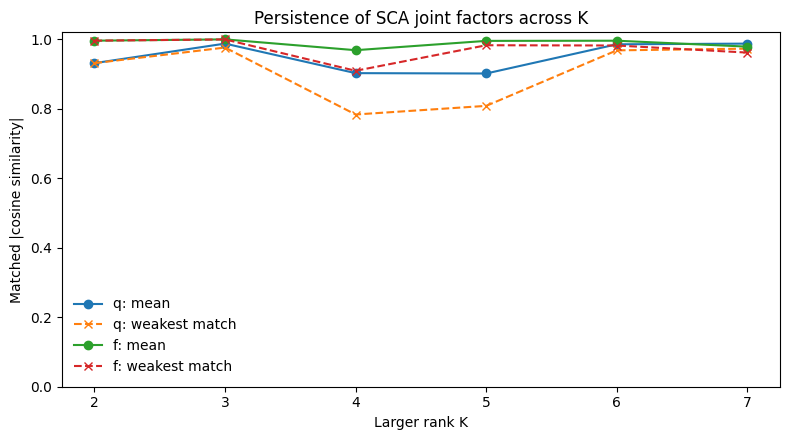

In [20]:
def match_loading_rows(V_a, V_b):
    A = row_normalize(V_a)
    B = row_normalize(V_b)
    similarity = np.abs(A @ B.T)
    rows, cols = linear_sum_assignment(-similarity)
    return rows, cols, similarity[rows, cols]

persistence_rows = []
for representation in ('q', 'f'):
    for k0, k1 in zip(AVAILABLE_K[:-1], AVAILABLE_K[1:]):
        V0 = load_sca_fit(representation, k0)['param_V']
        V1 = load_sca_fit(representation, k1)['param_V']
        rows, cols, scores = match_loading_rows(V0, V1)
        for old_i, new_i, score in zip(rows, cols, scores):
            persistence_rows.append({
                'representation': representation,
                'k_from': k0,
                'k_to': k1,
                'factor_from': int(old_i) + 1,
                'factor_to': int(new_i) + 1,
                'abs_cosine': float(score),
            })

persistence = pd.DataFrame(persistence_rows)
persistence.to_csv(ANALYSIS_OUTPUT / 'cross_k_factor_matches.csv', index=False)
display(persistence.head(20))

persistence_summary = (persistence
    .groupby(['representation', 'k_from', 'k_to'])['abs_cosine']
    .agg(['mean', 'median', 'min'])
    .reset_index())
display(persistence_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
for representation in ('q', 'f'):
    rows = persistence_summary[persistence_summary.representation == representation]
    ax.plot(rows.k_to, rows['mean'], marker='o', label=f'{representation}: mean')
    ax.plot(rows.k_to, rows['min'], marker='x', linestyle='--', label=f'{representation}: weakest match')
ax.set(xlabel='Larger rank K', ylabel='Matched |cosine similarity|', ylim=(0, 1.02),
       title='Persistence of SCA joint factors across K')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / 'sca_cross_k_persistence.png', bbox_inches='tight')
plt.show()


## 10. Compare the joint factors discovered from q and f

### Why

The reconstruction results already tell us that removing the endpoint baseline changes compactness. Here we ask a different question: **does residualization change the joint coordination axes themselves?**

If the same factors appear in both representations, endpoint removal may mainly affect how strongly/when those factors are recruited. If the factors differ substantially, `f` is exposing a different coordination geometry.

### How

At every K we compare the decoder rows from the `q` and `f` SCA fits using the same absolute-cosine + Hungarian matching procedure as above. Because both models have the same K, every factor receives one match.

### Interpretation

A high mean match indicates similar joint-loading substructures, but it does not imply identical temporal activation. That is why this comparison complements rather than replaces the activation analysis.


,k,q_factor,f_factor,abs_cosine
0,1,1,1,0.945766
1,2,1,1,0.818830
2,2,2,2,0.798743
3,3,1,1,0.781209
4,3,2,3,0.285684
5,3,3,2,0.772699
6,4,1,1,0.711894
7,4,2,4,0.498684
8,4,3,2,0.770224
9,4,4,3,0.685432


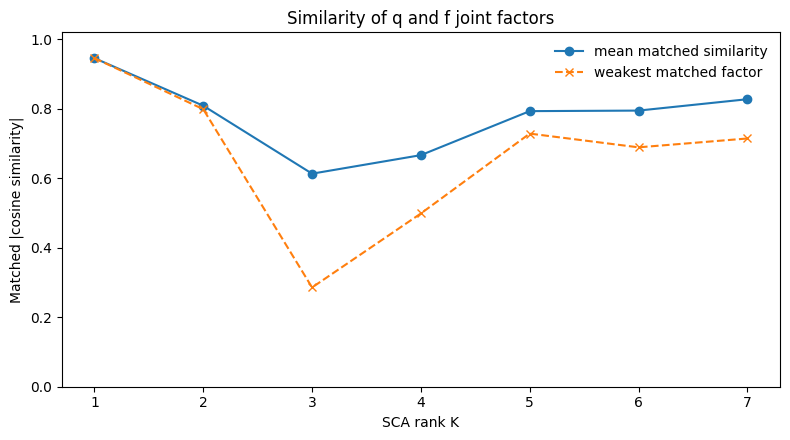

In [21]:
qf_rows = []
for k in AVAILABLE_K:
    Vq = load_sca_fit('q', k)['param_V']
    Vf = load_sca_fit('f', k)['param_V']
    rows, cols, scores = match_loading_rows(Vq, Vf)
    for qi, fi, score in zip(rows, cols, scores):
        qf_rows.append({
            'k': k,
            'q_factor': int(qi) + 1,
            'f_factor': int(fi) + 1,
            'abs_cosine': float(score),
        })

qf_matches = pd.DataFrame(qf_rows)
qf_matches.to_csv(ANALYSIS_OUTPUT / 'q_vs_f_factor_matches.csv', index=False)
display(qf_matches)

qf_summary = qf_matches.groupby('k')['abs_cosine'].agg(['mean', 'median', 'min']).reset_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(qf_summary.k, qf_summary['mean'], marker='o', label='mean matched similarity')
ax.plot(qf_summary.k, qf_summary['min'], marker='x', linestyle='--', label='weakest matched factor')
ax.set(xlabel='SCA rank K', ylabel='Matched |cosine similarity|', ylim=(0, 1.02),
       title='Similarity of q and f joint factors')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUT / 'q_vs_f_factor_similarity.png', bbox_inches='tight')
plt.show()


## 11. Compact SCA evidence table

### Why

SCA should be judged by more than reconstruction. This table combines reconstruction efficiency, the cost relative to PCA, latent sparsity and cross-K persistence.

### Metrics

For each representation and K:

- SCA test NMSE;
- PCA test NMSE at the same rank;
- SCA minus PCA NMSE;
- mean Hoyer sparsity on held-out samples;
- median effective factors per held-out trial;
- mean factor persistence from the previous K;
- mean `q`↔`f` loading similarity at that K.

### Interpretation

No row is automatically designated as the "best" rank. The full-rank row is especially important to interpret correctly: it is a reconstruction reference, not a candidate number of primitives.


In [23]:
rows = []
for representation in ('q', 'f'):
    for k in AVAILABLE_K:
        cmp_row = comparison[(comparison.representation == representation) & (comparison.k == k)].iloc[0]
        sparse_row = sparsity_summary[(sparsity_summary.representation == representation) &
                                      (sparsity_summary.k == k)].iloc[0]
        previous = persistence[(persistence.representation == representation) &
                               (persistence.k_to == k)]
        qf = qf_matches[qf_matches.k == k]
        rows.append({
            'representation': representation,
            'k': k,
            'sca_test_nmse': float(cmp_row['nmse']),
            'pca_test_nmse': float(cmp_row['test_nmse']),
            'sca_minus_pca_nmse': float(cmp_row['sca_minus_pca_nmse']),
            'mean_hoyer_sparsity': float(sparse_row['mean_hoyer_sparsity'])
                if k > 1 else np.nan,
            'median_effective_factors': float(sparse_row['median_effective_factors']),
            'mean_persistence_from_previous_k': (
                float(previous.abs_cosine.mean()) if len(previous) else np.nan),
            'mean_q_f_loading_similarity': float(qf.abs_cosine.mean()),
        })

sca_evidence = pd.DataFrame(rows)
sca_evidence.to_csv(ANALYSIS_OUTPUT / 'sca_evidence_table.csv', index=False)
display(sca_evidence)


,representation,k,sca_test_nmse,pca_test_nmse,sca_minus_pca_nmse,mean_hoyer_sparsity,median_effective_factors,mean_persistence_from_previous_k,mean_q_f_loading_similarity
0,q,1,6.189225e-01,6.183813e-01,5.411904e-04,NaN,1.000000,NaN,0.945766
1,q,2,3.305762e-01,3.303835e-01,1.927812e-04,0.360764,1.825180,0.931305,0.808786
2,q,3,2.226680e-01,2.226222e-01,4.580064e-05,0.346957,2.489202,0.987578,0.613197
3,q,4,1.421831e-01,1.421640e-01,1.906803e-05,0.326569,3.230479,0.902544,0.666558
4,q,5,8.016144e-02,8.015480e-02,6.643961e-06,0.335418,3.817019,0.901522,0.793190
5,q,6,2.852492e-02,2.852362e-02,1.300177e-06,0.337575,4.411485,0.985524,0.794764
6,q,7,1.029960e-10,7.531238e-31,1.029960e-10,0.535226,3.197951,0.987532,0.827493
7,f,1,5.779484e-01,5.757842e-01,2.164137e-03,NaN,1.000000,NaN,0.945766
8,f,2,3.147733e-01,3.144284e-01,3.448566e-04,0.350350,1.809347,0.995978,0.808786
9,f,3,2.092767e-01,2.091526e-01,1.240486e-04,0.350459,2.455333,0.999747,0.613197


## What this notebook can and cannot establish

SCA can provide evidence that movement trajectories occupy a compact, sparse joint-coordination space and can reveal which joint combinations are repeatedly active. It is particularly useful here as a comparison between raw trajectories `q` and endpoint residuals `f`.

It does **not** by itself identify the same object as a FADA spatiotemporal primitive. SCA activations are free to vary at every phase sample, so a stable SCA factor is best interpreted as a reusable **joint coordination axis**.

For this project, the most informative outcomes are therefore:

- how many joint-space dimensions are needed before reconstruction saturates;
- how much SCA reconstruction differs from PCA at the same rank;
- whether SCA actually achieves sparse latent recruitment;
- whether factor loadings persist across K and across `q`/`f`;
- whether those factors are broadly reused across subjects and conditions.

As with the FADA analysis, this notebook currently describes the `random_trial` baseline. A future held-out-subject or held-out-context experiment can reuse the same analysis structure by changing the result path.
